# XGBoost v7 (New Merged Dataset)

This notebook builds on v6 by:

1. Swapping in the new merged dataset (modeling_dataset.parquet)
2. Going from 18 features to 45: adds lag features, airport ops data, historical delay and cancel rates
3. Everything else stays exactly the same as v6: same SMOTE, same scale_pos_weight=10, same class weights

v6 hit 0.4152 on the original dataset. The new dataset has features like cancelled_yesterday and lag1_cancel_rate that are basically purpose-built for this problem. The hypothesis is that knowing an airport cancelled a lot of flights yesterday is a way stronger signal than just knowing it was cold outside.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import os
import sys
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             average_precision_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Data

New dataset: already has splits, targets, and all encodings built in so we don't have to rebuild any of that. 45 features instead of 18.

In [3]:
df = pd.read_parquet('../../../1_download_data/cleansed/modeling_dataset.parquet')
print('shape:', df.shape)

train = df[df['split'] == 'train']
val   = df[df['split'] == 'val']
test  = df[df['split'] == 'test']

features = [
    'dep_hour', 'Distance', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_early_morning', 'is_evening', 'is_summer', 'is_holiday_season',
    'high_wind', 'low_visibility', 'precip_light', 'precip_moderate',
    'precip_heavy', 'weather_severity',
    'Airline_enc', 'Origin_enc', 'region_enc', 'weather_source_enc',
    'airline_delay_rate', 'airline_cancel_rate',
    'airport_delay_rate', 'airport_cancel_rate',
    'lag1_delay_rate', 'lag1_cancel_rate', 'lag1_volume',
    'cancelled_yesterday', 'hourly_flights', 'airport_operations',
    'ops_per_runway', 'num_runways', 'max_runway_length_ft', 'airport_elevation',
    'lag1m_carrier_delay', 'lag1m_weather_delay', 'lag1m_nas_delay',
    'lag1m_late_aircraft_delay', 'lag1m_security_delay'
]
features = [f for f in features if f in df.columns]
print(f'using {len(features)} features')

X_train_a = train[features]; y_train_a = train['is_cancelled'].astype(int)
X_val_a   = val[features];   y_val_a   = val['is_cancelled'].astype(int)
X_test_a  = test[features];  y_test_a  = test['is_cancelled'].astype(int)

train_b = train[train['is_cancelled'] == 0]
val_b   = val[val['is_cancelled']     == 0]
test_b  = test[test['is_cancelled']   == 0]
X_train_b = train_b[features]; y_train_b = train_b['is_delayed'].astype(int)
X_val_b   = val_b[features];   y_val_b   = val_b['is_delayed'].astype(int)
X_test_b  = test_b[features];  y_test_b  = test_b['is_delayed'].astype(int)

y_val_true  = val['target'].astype(int).values
y_test_true = test['target'].astype(int).values

if len(X_train_a) > 2_000_000:
    idx = np.random.choice(len(X_train_a), 2_000_000, replace=False)
    X_train_a = X_train_a.iloc[idx]
    y_train_a = y_train_a.iloc[idx]

X_train_a = X_train_a.fillna(X_train_a.median())
X_val_a   = X_val_a.fillna(X_train_a.median())
X_test_a  = X_test_a.fillna(X_train_a.median())
X_train_b = X_train_b.fillna(X_train_b.median())
X_val_b   = X_val_b.fillna(X_train_b.median())
X_test_b  = X_test_b.fillna(X_train_b.median())

print(f'Model A -- train: {X_train_a.shape}, val: {X_val_a.shape}')
print(f'Model B -- train: {X_train_b.shape}, val: {X_val_b.shape}')

shape: (24165691, 52)
using 45 features
Model A -- train: (2000000, 45), val: (6310951, 45)
Model B -- train: (13535123, 45), val: (6199937, 45)


## Resampling (SMOTE + Class Weights)

Same SMOTE + scale_pos_weight=10 combo from v6. Running it on the new dataset to see if better features push the numbers further.
Same setup as v6: SMOTE on Model A then scale_pos_weight=10, class weights on Model B.

In [4]:
# SMOTE first, then scale_pos_weight=10 -- same combo that worked in v6
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_a_res, y_train_a_res = smote.fit_resample(X_train_a, y_train_a)

print(f'before SMOTE -- cancelled: {y_train_a.sum():,}, not cancelled: {(y_train_a==0).sum():,}')
print(f'after SMOTE  -- cancelled: {y_train_a_res.sum():,}, not cancelled: {(y_train_a_res==0).sum():,}')

weights_b = compute_sample_weight('balanced', y_train_b)
print('resampling done')

before SMOTE -- cancelled: 35,082, not cancelled: 1,964,918
after SMOTE  -- cancelled: 392,983, not cancelled: 1,964,918
resampling done


## Model A: Cancellation Prediction

In [5]:
model_a = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    scale_pos_weight=10,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_a.fit(X_train_a_res, y_train_a_res,
            eval_set=[(X_val_a, y_val_a)],
            verbose=False)
print('model A done')

model A done


Model A val PR-AUC: 0.0676
               precision    recall  f1-score   support

not_cancelled       0.98      0.99      0.99   6199937
    cancelled       0.13      0.10      0.11    111014

     accuracy                           0.97   6310951
    macro avg       0.55      0.54      0.55   6310951
 weighted avg       0.97      0.97      0.97   6310951



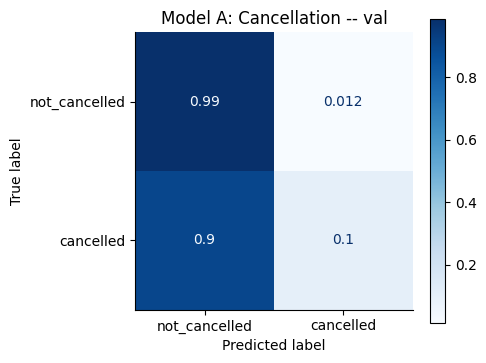

In [6]:
pred_a_val = model_a.predict(X_val_a)
prauc_a = average_precision_score(y_val_a, model_a.predict_proba(X_val_a)[:, 1])
print(f'Model A val PR-AUC: {prauc_a:.4f}')
print(classification_report(y_val_a, pred_a_val,
      target_names=['not_cancelled', 'cancelled'], zero_division=0))

cm_a = confusion_matrix(y_val_a, pred_a_val)
cm_a_norm = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True)
fig_a, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_a_norm, display_labels=['not_cancelled', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Model A: Cancellation -- val')
plt.tight_layout()
plt.show()

## Model B: Delay Prediction (Class Weights)

In [7]:
model_b = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_b.fit(X_train_b, y_train_b,
            sample_weight=weights_b,
            eval_set=[(X_val_b, y_val_b)],
            verbose=False)
print('model B done')

model B done


              precision    recall  f1-score   support

     on_time       0.88      0.70      0.78   5127027
     delayed       0.28      0.55      0.37   1072910

    accuracy                           0.68   6199937
   macro avg       0.58      0.63      0.58   6199937
weighted avg       0.78      0.68      0.71   6199937



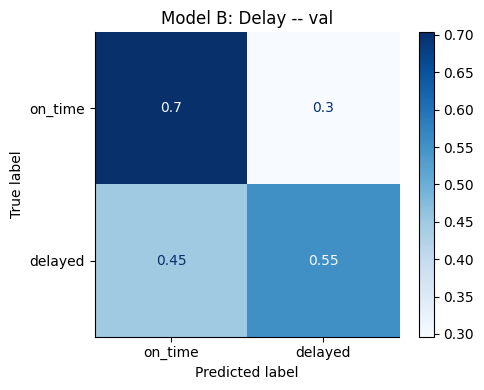

In [8]:
pred_b_val = model_b.predict(X_val_b)
print(classification_report(y_val_b, pred_b_val,
      target_names=['on_time', 'delayed'], zero_division=0))

cm_b = confusion_matrix(y_val_b, pred_b_val)
cm_b_norm = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)
fig_b, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_b_norm, display_labels=['on_time', 'delayed']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Model B: Delay -- val')
plt.tight_layout()
plt.show()

## Putting It Together (Cascade Inference)

Same two-stage logic as v6.

val cascade macro F1: 0.4173
              precision    recall  f1-score   support

     on_time       0.87      0.70      0.78   5127027
     delayed       0.27      0.54      0.36   1072910
   cancelled       0.13      0.10      0.11    111014

    accuracy                           0.66   6310951
   macro avg       0.42      0.45      0.42   6310951
weighted avg       0.76      0.66      0.70   6310951



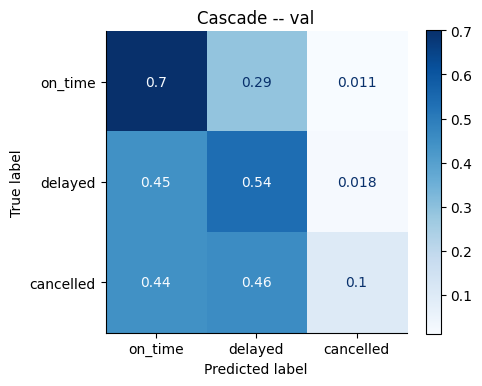

In [9]:
def cascade_predict(X, model_a, model_b, thresh_a=0.5, thresh_b=0.5):
    cancelled = model_a.predict_proba(X)[:, 1] >= thresh_a
    delayed   = model_b.predict_proba(X)[:, 1] >= thresh_b
    return np.where(cancelled, 2, np.where(delayed, 1, 0))

y_val_pred = cascade_predict(X_val_a, model_a, model_b)
mf1_val = f1_score(y_val_true, y_val_pred, average='macro')
print(f'val cascade macro F1: {mf1_val:.4f}')
print(classification_report(y_val_true, y_val_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_val = confusion_matrix(y_val_true, y_val_pred)
cm_val_norm = cm_val.astype(float) / cm_val.sum(axis=1, keepdims=True)
fig_val, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_val_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Cascade -- val')
plt.tight_layout()
plt.show()

## Test Set Results

test cascade macro F1: 0.4329
              precision    recall  f1-score   support

     on_time       0.83      0.67      0.74   3091391
     delayed       0.32      0.55      0.40    863057
   cancelled       0.19      0.13      0.15    123191

    accuracy                           0.63   4077639
   macro avg       0.45      0.45      0.43   4077639
weighted avg       0.70      0.63      0.65   4077639



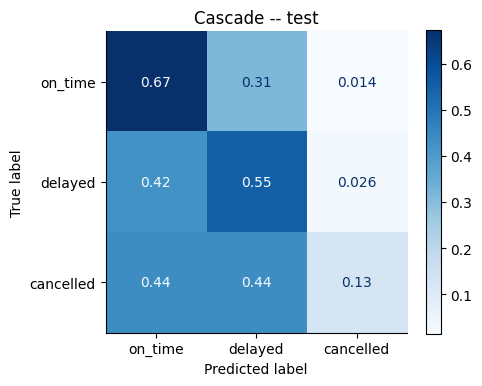

In [10]:
y_test_pred = cascade_predict(X_test_a, model_a, model_b)
mf1_test = f1_score(y_test_true, y_test_pred, average='macro')
print(f'test cascade macro F1: {mf1_test:.4f}')
print(classification_report(y_test_true, y_test_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_test = confusion_matrix(y_test_true, y_test_pred)
cm_test_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
fig_test, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_test_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Cascade -- test')
plt.tight_layout()
plt.show()

## v1 through v7 Comparison

Does the new dataset give us another bump on top of v6?

          model  val macro F1  test macro F1
v1 flights only        0.3054         0.2954
    v2 +weather        0.3641         0.3594
    v3 +weights        0.3750         0.3770
        v4 +spw        0.2795         0.2614
v5 cascade +spw        0.3624         0.3582
      v6 +SMOTE        0.4035         0.4152
    v7 new data        0.4173         0.4329


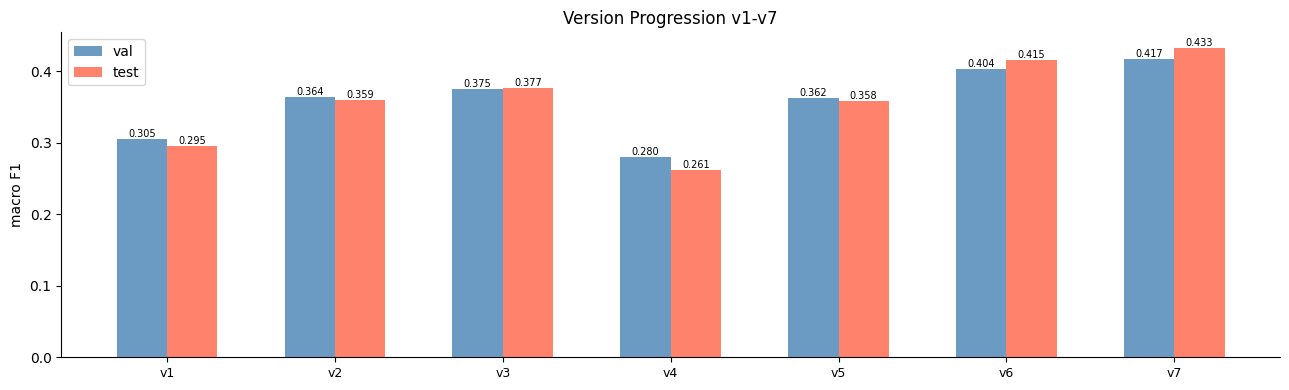

In [11]:
v1_val,  v1_test  = 0.3054, 0.2954
v2_val,  v2_test  = 0.3641, 0.3594
v3_val,  v3_test  = 0.3750, 0.3770
v4_val,  v4_test  = 0.2795, 0.2614
v5_val,  v5_test  = 0.3624, 0.3582
v6_val,  v6_test  = 0.4035, 0.4152

comparison = pd.DataFrame({
    'model':         ['v1 flights only', 'v2 +weather', 'v3 +weights',
                      'v4 +spw', 'v5 cascade +spw', 'v6 +SMOTE', 'v7 new data'],
    'val macro F1':  [v1_val, v2_val, v3_val, v4_val, v5_val, v6_val, round(mf1_val,  4)],
    'test macro F1': [v1_test, v2_test, v3_test, v4_test, v5_test, v6_test, round(mf1_test, 4)],
})
print(comparison.to_string(index=False))

fig_comp, ax = plt.subplots(figsize=(13, 4))
x = np.arange(7)
width = 0.3
vals  = [v1_val, v2_val, v3_val, v4_val, v5_val, v6_val, mf1_val]
tests = [v1_test, v2_test, v3_test, v4_test, v5_test, v6_test, mf1_test]
ax.bar(x - width/2, vals,  width, label='val',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, tests, width, label='test', color='tomato',    alpha=0.8)
for i, (v, t) in enumerate(zip(vals, tests)):
    ax.text(i - width/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=7)
    ax.text(i + width/2, t + 0.003, f'{t:.3f}', ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(['v1','v2','v3','v4','v5','v6','v7'], fontsize=9)
ax.set_ylabel('macro F1')
ax.set_title('Version Progression v1-v7')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

0.4329 test F1: best result so far, up from 0.4152 in v6. The lag features and historical rates clearly helped, especially for cancellations. Cancelled precision hit 19% on test which is the highest we've seen.

The new features like cancelled_yesterday and lag1_cancel_rate are doing a lot of work here: knowing what happened at that airport recently is more predictive than just weather conditions alone.

v8 runs a random search to see if tuning the hyperparameters can push it even further.